In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers, datasets

In [2]:
# 1. Load MNIST dataset
# --------------------------------------------------

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 18s 2us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [3]:
# 2. Normalize images
# --------------------------------------------------

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Normalization completed.")

Normalization completed.


In [5]:
# 3. Create MLP model
# --------------------------------------------------

model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(10, activation="softmax")
])

In [6]:
# 4. Compile model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 5. Train model
# --------------------------------------------------

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8988 - loss: 0.3487 - val_accuracy: 0.9445 - val_loss: 0.1819
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - loss: 0.1341 - val_accuracy: 0.9635 - val_loss: 0.1243
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0939 - val_accuracy: 0.9646 - val_loss: 0.1120
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9770 - loss: 0.0744 - val_accuracy: 0.9728 - val_loss: 0.0874
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9812 - loss: 0.0581 - val_accuracy: 0.9749 - val_loss: 0.0802
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9852 - loss: 0.0458 - val_accuracy: 0.9730 - val_loss: 0.0847
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9875 - loss: 0.0389 - val_accuracy: 0.9748 - val_loss: 0.0816
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9902 - loss: 0.0317 - val_accuracy: 0.

In [9]:
# 6. Evaluate model
# --------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print("\nMNIST Test Loss:", test_loss)
print("MNIST Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.0934

MNIST Test Loss: 0.09338920563459396
MNIST Test Accuracy: 0.9739999771118164


In [10]:
# 7. Save model
# --------------------------------------------------

model.save("mnist_model.keras")

print("\nMNIST model saved as mnist_model.keras")


MNIST model saved as mnist_model.keras


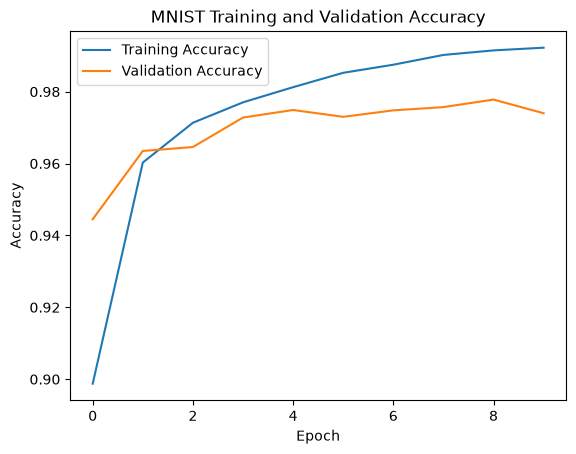

In [11]:
# 8. Plot accuracy
# --------------------------------------------------

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Training and Validation Accuracy")
plt.legend()
plt.show()

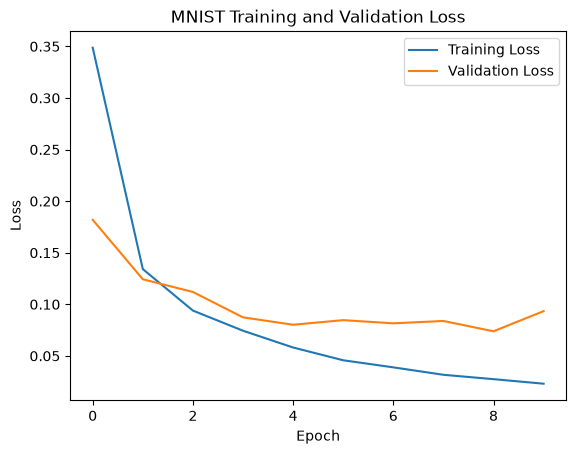

In [12]:
# 9. Plot loss
# --------------------------------------------------

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training and Validation Loss")
plt.legend()
plt.show()